In [1]:
#instaling polars

!pip install -q polars
!pip install -q pyarrow

In [2]:
import polars as pl
import sys

print("Python Version :", sys.version.split()[0])
print("Polars Version :", pl.__version__)

Python Version : 3.12.13
Polars Version : 1.35.2


In [3]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Create project folder structure
!mkdir -p /content/drive/MyDrive/developer_career_intelligence/data/raw
!mkdir -p /content/drive/MyDrive/developer_career_intelligence/data/cleaned
!mkdir -p /content/drive/MyDrive/developer_career_intelligence/data/warehouse
!mkdir -p /content/drive/MyDrive/developer_career_intelligence/exports

print("Folders ready.")

Folders ready.


In [5]:
# Verify all survey files are uploaded correctly
import os

RAW_PATH = '/content/drive/MyDrive/developer_career_intelligence/data/raw'

files = os.listdir(RAW_PATH)

print("Files found in raw folder:\n")

total_size = 0

for file in sorted(files):
    size = os.path.getsize(f'{RAW_PATH}/{file}')
    size_mb = round(size / (1024 * 1024), 2)
    total_size += size_mb
    print(f"  {file}  —  {size_mb} MB")

print(f"\n  Total files   : {len(files)}")
print(f"  Total size    : {round(total_size, 2)} MB")

Files found in raw folder:

  survey_2020.csv  —  90.22 MB
  survey_2021.csv  —  77.34 MB
  survey_2022.csv  —  103.79 MB
  survey_2023.csv  —  151.28 MB
  survey_2024.csv  —  152.14 MB
  survey_2025.csv  —  134.37 MB

  Total files   : 6
  Total size    : 709.14 MB


In [6]:
# CELL 5 — Load Each Year and Explore Basic Shape

import polars as pl
import os

RAW_PATH = '/content/drive/MyDrive/developer_career_intelligence/data/raw'


survey_data = {}

years = [2020, 2021, 2022, 2023, 2024, 2025]

print("Loading survey files...\n")
print("=" * 55)

for year in years:
    file_path = f'{RAW_PATH}/survey_{year}.csv'


    df = pl.read_csv(file_path, infer_schema_length=0)

    # Store in dictionary with year as key
    survey_data[year] = df

    # Print basic info
    print(f"\n  Year    : {year}")
    print(f"  Rows    : {df.shape[0]:,}")
    print(f"  Columns : {df.shape[1]}")
    print("=" * 55)

print("\nAll 6 years loaded successfully into survey_data dictionary.")

Loading survey files...


  Year    : 2020
  Rows    : 64,461
  Columns : 61

  Year    : 2021
  Rows    : 83,439
  Columns : 48

  Year    : 2022
  Rows    : 73,268
  Columns : 79

  Year    : 2023
  Rows    : 89,184
  Columns : 84

  Year    : 2024
  Rows    : 65,437
  Columns : 114

  Year    : 2025
  Rows    : 49,191
  Columns : 172

All 6 years loaded successfully into survey_data dictionary.


In [7]:


for year in years:
    df = survey_data[year]
    cols = df.columns

    print(f"\n{'=' * 55}")
    print(f"  YEAR {year} — {len(cols)} columns")
    print(f"{'=' * 55}")

    for i, col in enumerate(cols, 1):
        print(f"  {i:3}. {col}")


  YEAR 2020 — 61 columns
    1. Respondent
    2. MainBranch
    3. Hobbyist
    4. Age
    5. Age1stCode
    6. CompFreq
    7. CompTotal
    8. ConvertedComp
    9. Country
   10. CurrencyDesc
   11. CurrencySymbol
   12. DatabaseDesireNextYear
   13. DatabaseWorkedWith
   14. DevType
   15. EdLevel
   16. Employment
   17. Ethnicity
   18. Gender
   19. JobFactors
   20. JobSat
   21. JobSeek
   22. LanguageDesireNextYear
   23. LanguageWorkedWith
   24. MiscTechDesireNextYear
   25. MiscTechWorkedWith
   26. NEWCollabToolsDesireNextYear
   27. NEWCollabToolsWorkedWith
   28. NEWDevOps
   29. NEWDevOpsImpt
   30. NEWEdImpt
   31. NEWJobHunt
   32. NEWJobHuntResearch
   33. NEWLearn
   34. NEWOffTopic
   35. NEWOnboardGood
   36. NEWOtherComms
   37. NEWOvertime
   38. NEWPurchaseResearch
   39. NEWPurpleLink
   40. NEWSOSites
   41. NEWStuck
   42. OpSys
   43. OrgSize
   44. PlatformDesireNextYear
   45. PlatformWorkedWith
   46. PurchaseWhat
   47. Sexuality
   48. SOAccount
   4

In [8]:

# CELL 7 — Column Mapping
STANDARD_MAP = {
    'ResponseId'              : 'respondent_id',
    'MainBranch'              : 'main_branch',
    'Employment'              : 'employment',
    'Country'                 : 'country',
    'EdLevel'                 : 'ed_level',
    'Age'                     : 'age',
    'YearsCode'               : 'years_code',
    'YearsCodePro'            : 'years_code_pro',
    'DevType'                 : 'dev_type',
    'OrgSize'                 : 'org_size',
    'ConvertedCompYearly'     : 'salary_usd',
    'LanguageHaveWorkedWith'  : 'language_worked_with',
    'DatabaseHaveWorkedWith'  : 'database_worked_with',
    'PlatformHaveWorkedWith'  : 'platform_worked_with',
    'WebframeHaveWorkedWith'  : 'webframe_worked_with',
    'OpSysProfessional use'   : 'op_sys',
    'RemoteWork'              : 'remote_work',
}

# Only define exceptions — columns that differ from standard
EXCEPTIONS = {
    2020: {
        'Respondent'          : 'respondent_id',
        'ConvertedComp'       : 'salary_usd',       # different salary name
        'LanguageWorkedWith'  : 'language_worked_with',
        'DatabaseWorkedWith'  : 'database_worked_with',
        'PlatformWorkedWith'  : 'platform_worked_with',
        'WebframeWorkedWith'  : 'webframe_worked_with',
        'OpSys'               : 'op_sys',
    },
    2021: {
        'OpSys'               : 'op_sys',           # different op sys name
    },
    2025: {
        'WorkExp'             : 'years_code_pro',   # different experience name
    },
}

# Build final mapping per year by merging standard + exceptions
column_maps = {}

for year in [2020, 2021, 2022, 2023, 2024, 2025]:
    # Start with standard map
    merged = STANDARD_MAP.copy()
    # Override with year specific exceptions
    if year in EXCEPTIONS:
        merged.update(EXCEPTIONS[year])
    column_maps[year] = merged

print("Column maps built for all 6 years.")
print(f"\nTotal standard columns : {len(STANDARD_MAP)}")
print(f"Years with exceptions  : {list(EXCEPTIONS.keys())}")

Column maps built for all 6 years.

Total standard columns : 17
Years with exceptions  : [2020, 2021, 2025]


In [9]:

# CELL 8 — Select & Rename Columns Per Year


cleaned_data = {}

for year in [2020, 2021, 2022, 2023, 2024, 2025]:
    df = survey_data[year]
    mapping = column_maps[year]

    # Keep only columns that exist in both the mapping AND the dataframe
    # Some mapped columns may not exist in certain years
    valid_cols = {old: new for old, new in mapping.items() if old in df.columns}

    # Select only those columns and rename them
    df_cleaned = df.select(valid_cols.keys()).rename(valid_cols)

    # Add a year column so we know which year each row came from
    df_cleaned = df_cleaned.with_columns(pl.lit(year).alias('survey_year'))

    cleaned_data[year] = df_cleaned

    print(f"{year} → {df_cleaned.shape[0]:,} rows, {df_cleaned.shape[1]} columns")

print("\nAll years cleaned successfully.")

2020 → 64,461 rows, 17 columns
2021 → 83,439 rows, 17 columns
2022 → 73,268 rows, 18 columns
2023 → 89,184 rows, 18 columns
2024 → 65,437 rows, 18 columns
2025 → 49,191 rows, 18 columns

All years cleaned successfully.


In [10]:
# ============================================================
# CELL 9 — Merge All Years Into Master Dataset
# ============================================================

# Stack all 6 years vertically into one dataframe
# how='diagonal_relaxed' handles cases where some years
# have columns others don't — fills missing with null
master_df = pl.concat(
    [cleaned_data[year] for year in [2020, 2021, 2022, 2023, 2024, 2025]],
    how='diagonal_relaxed'
)

print(f"Master dataset shape : {master_df.shape[0]:,} rows x {master_df.shape[1]} columns")
print(f"\nColumns in master dataset:\n")
for i, col in enumerate(master_df.columns, 1):
    print(f"  {i:2}. {col}")

Master dataset shape : 424,980 rows x 18 columns

Columns in master dataset:

   1. main_branch
   2. employment
   3. country
   4. ed_level
   5. age
   6. years_code
   7. years_code_pro
   8. dev_type
   9. org_size
  10. respondent_id
  11. salary_usd
  12. language_worked_with
  13. database_worked_with
  14. platform_worked_with
  15. webframe_worked_with
  16. op_sys
  17. survey_year
  18. remote_work


In [11]:
# ============================================================
# CELL 10 — Data Quality Check
# ============================================================

print(f"Total rows : {master_df.shape[0]:,}")
print(f"Total cols : {master_df.shape[1]}")

print(f"\n--- Null Values Per Column ---\n")

null_counts = master_df.null_count()

for col in master_df.columns:
    nulls = null_counts[col][0]
    pct = round((nulls / master_df.shape[0]) * 100, 1)
    bar = '█' * int(pct / 2)
    print(f"  {col:<25} {nulls:>7,} nulls  ({pct:>5}%)  {bar}")

Total rows : 424,980
Total cols : 18

--- Null Values Per Column ---

  main_branch                     0 nulls  (  0.0%)  
  employment                      0 nulls  (  0.0%)  
  country                         0 nulls  (  0.0%)  
  ed_level                        0 nulls  (  0.0%)  
  age                             0 nulls  (  0.0%)  
  years_code                      0 nulls  (  0.0%)  
  years_code_pro                  0 nulls  (  0.0%)  
  dev_type                        0 nulls  (  0.0%)  
  org_size                        0 nulls  (  0.0%)  
  respondent_id                   0 nulls  (  0.0%)  
  salary_usd                      0 nulls  (  0.0%)  
  language_worked_with            0 nulls  (  0.0%)  
  database_worked_with            0 nulls  (  0.0%)  
  platform_worked_with            0 nulls  (  0.0%)  
  webframe_worked_with            0 nulls  (  0.0%)  
  op_sys                     20,174 nulls  (  4.7%)  ██
  survey_year                     0 nulls  (  0.0%)  
  remote_w

In [12]:
# ============================================================
# CELL 11 — Replace String NAs With Real Nulls (Fixed)
# ============================================================

na_values = ["NA", "na", "N/A", "n/a", "", "nan", "NaN", "NULL", "null", "None"]

# Only apply to string columns — skip integer columns like survey_year
string_cols = [col for col in master_df.columns if master_df[col].dtype == pl.Utf8]

master_df = master_df.with_columns([
    pl.when(pl.col(col).is_in(na_values))
    .then(None)
    .otherwise(pl.col(col))
    .alias(col)
    for col in string_cols
])

print("NA strings replaced with real nulls.")
print(f"\n--- Null Values After Fix ---\n")

null_counts = master_df.null_count()

for col in master_df.columns:
    nulls = null_counts[col][0]
    pct = round((nulls / master_df.shape[0]) * 100, 1)
    bar = '█' * int(pct / 2)
    print(f"  {col:<25} {nulls:>7,} nulls  ({pct:>5}%)  {bar}")

NA strings replaced with real nulls.

--- Null Values After Fix ---

  main_branch                   299 nulls  (  0.1%)  
  employment                  4,420 nulls  (  1.0%)  
  country                    23,358 nulls  (  5.5%)  ██
  ed_level                   15,946 nulls  (  3.8%)  █
  age                        22,369 nulls  (  5.3%)  ██
  years_code                 23,978 nulls  (  5.6%)  ██
  years_code_pro            104,943 nulls  ( 24.7%)  ████████████
  dev_type                   67,827 nulls  ( 16.0%)  ████████
  org_size                  122,180 nulls  ( 28.7%)  ██████████████
  respondent_id                   0 nulls  (  0.0%)  
  salary_usd                209,908 nulls  ( 49.4%)  ████████████████████████
  language_worked_with       35,714 nulls  (  8.4%)  ████
  database_worked_with       96,537 nulls  ( 22.7%)  ███████████
  platform_worked_with      138,826 nulls  ( 32.7%)  ████████████████
  webframe_worked_with      132,359 nulls  ( 31.1%)  ███████████████
  op_sys  

In [13]:
# ============================================================
# CELL 12 — Save Master Dataset as Parquet
# ============================================================

import os

WAREHOUSE_PATH = '/content/drive/MyDrive/developer_career_intelligence/data/warehouse'

save_path = f'{WAREHOUSE_PATH}/master_survey.parquet'

master_df.write_parquet(save_path)

# Verify it saved correctly
file_size = os.path.getsize(save_path)
file_size_mb = round(file_size / (1024 * 1024), 2)

print(f"Master dataset saved successfully.")
print(f"\nLocation : {save_path}")
print(f"Size     : {file_size_mb} MB")
print(f"Rows     : {master_df.shape[0]:,}")
print(f"Columns  : {master_df.shape[1]}")
print(f"\nParquet vs Raw CSVs:")
print(f"  Raw CSVs total  : 709.14 MB")
print(f"  Parquet file    : {file_size_mb} MB")
print(f"  Size reduction  : {round(100 - (file_size_mb/709.14)*100, 1)}%")

Master dataset saved successfully.

Location : /content/drive/MyDrive/developer_career_intelligence/data/warehouse/master_survey.parquet
Size     : 8.65 MB
Rows     : 424,980
Columns  : 18

Parquet vs Raw CSVs:
  Raw CSVs total  : 709.14 MB
  Parquet file    : 8.65 MB
  Size reduction  : 98.8%


In [14]:
# ============================================================
# CELL 13 — Developer Role Distribution
# ============================================================

# Drop rows where dev_type is null
dev_df = master_df.filter(pl.col('dev_type').is_not_null())

# Split the semicolon separated roles and explode into individual rows
# Each role becomes its own row
role_df = (
    dev_df
    .select('dev_type')
    .with_columns(
        pl.col('dev_type').str.split(';').alias('dev_type')
    )
    .explode('dev_type')
    .with_columns(
        pl.col('dev_type').str.strip_chars().alias('dev_type')
    )
    .filter(pl.col('dev_type') != '')
)

# Count each role
role_counts = (
    role_df
    .group_by('dev_type')
    .agg(pl.len().alias('count'))
    .sort('count', descending=True)
)

print("Top 20 Developer Roles Across All Years\n")
print(f"{'Rank':<5} {'Role':<50} {'Count':>10}")
print("-" * 68)

for i, row in enumerate(role_counts.head(20).iter_rows(), 1):
    print(f"{i:<5} {row[0]:<50} {row[1]:>10,}")

Top 20 Developer Roles Across All Years

Rank  Role                                                    Count
--------------------------------------------------------------------
1     Developer, full-stack                                 145,063
2     Developer, back-end                                   113,020
3     Developer, front-end                                   62,836
4     Developer, desktop or enterprise applications          40,682
5     Developer, mobile                                      32,925
6     DevOps specialist                                      21,603
7     Student                                                19,888
8     Developer, embedded applications or devices            18,013
9     System administrator                                   18,004
10    Database administrator                                 16,739
11    Engineering manager                                    14,484
12    Data scientist or machine learning specialist          14,297
13    

In [15]:
!pip install -q matplotlib

In [16]:

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

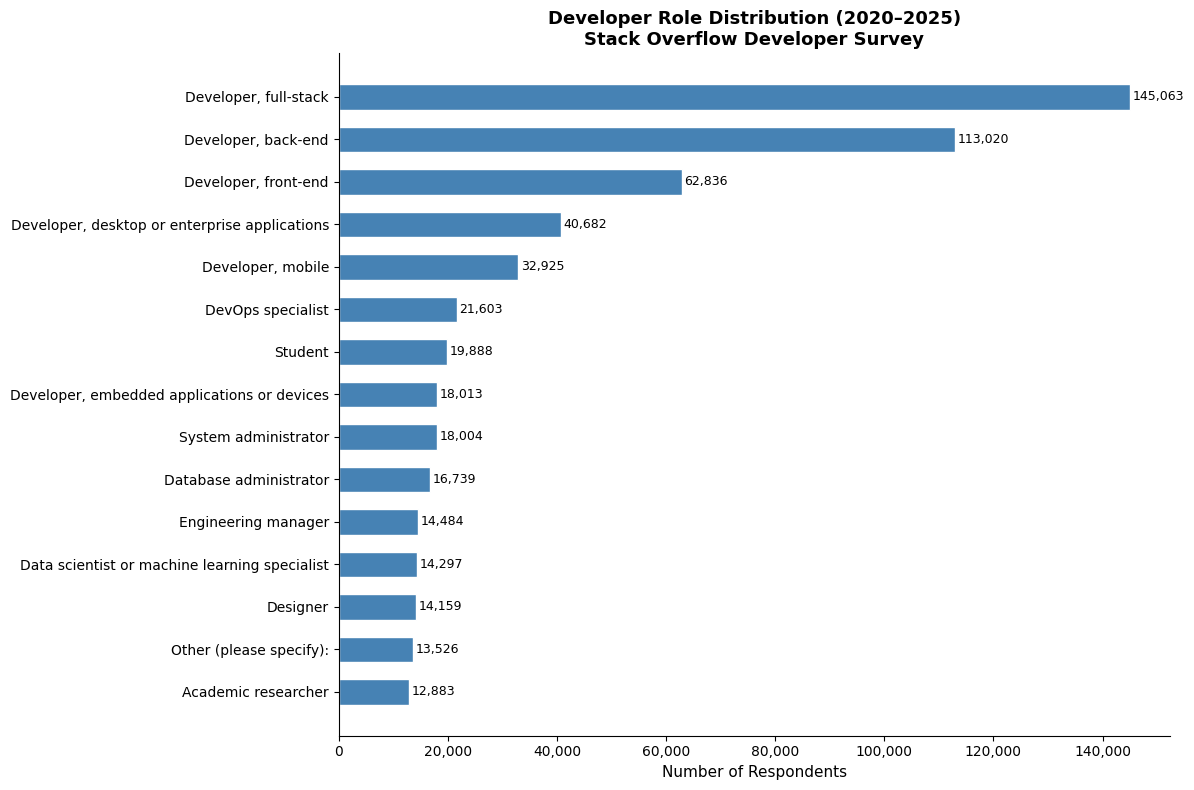

Chart saved to exports folder.


In [17]:
# ============================================================
# CELL 14 — Visualize Developer Role Distribution
# ============================================================

# Take top 15 roles only for clean chart
top_roles = role_counts.head(15)

roles = top_roles['dev_type'].to_list()
counts = top_roles['count'].to_list()

# Reverse so largest bar appears at top
roles = roles[::-1]
counts = counts[::-1]

# Create horizontal bar chart
fig, ax = plt.subplots(figsize=(12, 8))

bars = ax.barh(roles, counts, color='steelblue', edgecolor='white', height=0.6)

# Add count labels at end of each bar
for bar, count in zip(bars, counts):
    ax.text(
        bar.get_width() + 500,
        bar.get_y() + bar.get_height() / 2,
        f'{count:,}',
        va='center',
        fontsize=9
    )

ax.set_xlabel('Number of Respondents', fontsize=11)
ax.set_title('Developer Role Distribution (2020–2025)\nStack Overflow Developer Survey', fontsize=13, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

# Save to exports folder
plt.savefig('/content/drive/MyDrive/developer_career_intelligence/exports/role_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved to exports folder.")

In [18]:
# ============================================================
# CELL 15 — Salary Data Cleaning
# ============================================================

# Convert salary from string to float
# errors='null' means if conversion fails, put null instead of crashing
salary_df = master_df.with_columns(
    pl.col('salary_usd').cast(pl.Float64, strict=False).alias('salary_usd')
)

# Check before filtering
total = salary_df.shape[0]
has_salary = salary_df.filter(pl.col('salary_usd').is_not_null()).shape[0]

print(f"Total rows          : {total:,}")
print(f"Rows with salary    : {has_salary:,}")
print(f"Rows without salary : {total - has_salary:,}")

# Remove outliers
# Salary below 1000 USD/year is unrealistic
# Salary above 500000 USD/year is extreme outlier
salary_df = salary_df.filter(
    pl.col('salary_usd').is_not_null() &
    (pl.col('salary_usd') >= 1000) &
    (pl.col('salary_usd') <= 500000)
)

print(f"\nAfter removing outliers : {salary_df.shape[0]:,} rows")

# Basic salary statistics
stats = salary_df.select(
    pl.col('salary_usd').min().alias('min'),
    pl.col('salary_usd').max().alias('max'),
    pl.col('salary_usd').mean().alias('mean'),
    pl.col('salary_usd').median().alias('median'),
)

print(f"\n--- Salary Statistics (USD/Year) ---\n")
print(f"  Minimum  : ${stats['min'][0]:>12,.0f}")
print(f"  Maximum  : ${stats['max'][0]:>12,.0f}")
print(f"  Mean     : ${stats['mean'][0]:>12,.0f}")
print(f"  Median   : ${stats['median'][0]:>12,.0f}")

Total rows          : 424,980
Rows with salary    : 215,072
Rows without salary : 209,908

After removing outliers : 207,601 rows

--- Salary Statistics (USD/Year) ---

  Minimum  : $       1,000
  Maximum  : $     500,000
  Mean     : $      80,732
  Median   : $      64,630


In [19]:
# ============================================================
# CELL 16 — Salary by Developer Role
# ============================================================

# Split dev_type and explode same as Cell 13
# But this time keep salary too
role_salary = (
    salary_df
    .filter(pl.col('dev_type').is_not_null())
    .select(['dev_type', 'salary_usd'])
    .with_columns(
        pl.col('dev_type').str.split(';').alias('dev_type')
    )
    .explode('dev_type')
    .with_columns(
        pl.col('dev_type').str.strip_chars().alias('dev_type')
    )
    .filter(pl.col('dev_type') != '')
)

# Calculate median salary per role
# Only keep roles with at least 500 responses for reliability
role_salary_agg = (
    role_salary
    .group_by('dev_type')
    .agg([
        pl.col('salary_usd').median().alias('median_salary'),
        pl.col('salary_usd').count().alias('count')
    ])
    .filter(pl.col('count') >= 500)
    .sort('median_salary', descending=True)
)

print("Median Salary by Developer Role (USD/Year)\n")
print(f"{'Rank':<5} {'Role':<50} {'Median Salary':>15} {'Responses':>10}")
print("-" * 83)

for i, row in enumerate(role_salary_agg.head(20).iter_rows(), 1):
    print(f"{i:<5} {row[0]:<50} ${row[1]:>13,.0f} {row[2]:>10,}")

Median Salary by Developer Role (USD/Year)

Rank  Role                                                 Median Salary  Responses
-----------------------------------------------------------------------------------
1     Senior Executive (C-Suite, VP, etc.)               $      105,612      3,272
2     Engineering manager                                $      103,408      9,269
3     Architect, software or solutions                   $      102,093      1,589
4     Cloud infrastructure engineer                      $       89,768      4,848
5     Security professional                              $       89,347      1,418
6     Senior executive/VP                                $       87,198        732
7     DevOps engineer or professional                    $       87,011        680
8     Engineer, site reliability                         $       85,563      4,849
9     Research & Development role                        $       82,703      1,203
10    Blockchain                         

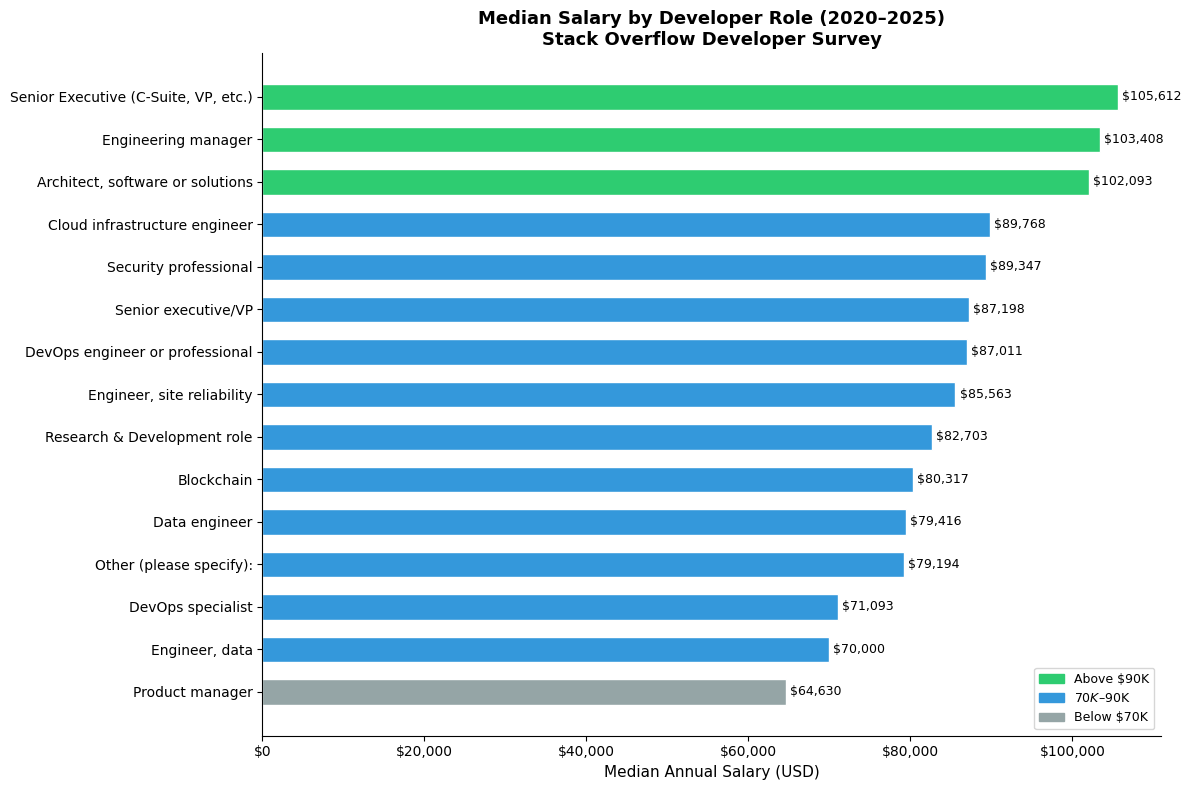

Chart saved.


In [20]:
# ============================================================
# CELL 17 — Visualize Salary by Developer Role
# ============================================================

top_roles_salary = role_salary_agg.head(15)

roles  = top_roles_salary['dev_type'].to_list()[::-1]
salary = top_roles_salary['median_salary'].to_list()[::-1]

fig, ax = plt.subplots(figsize=(12, 8))

colors = ['#2ecc71' if s >= 90000 else '#3498db' if s >= 70000 else '#95a5a6' for s in salary]

bars = ax.barh(roles, salary, color=colors, edgecolor='white', height=0.6)

# Add salary labels
for bar, val in zip(bars, salary):
    ax.text(
        bar.get_width() + 500,
        bar.get_y() + bar.get_height() / 2,
        f'${val:,.0f}',
        va='center',
        fontsize=9
    )

ax.set_xlabel('Median Annual Salary (USD)', fontsize=11)
ax.set_title('Median Salary by Developer Role (2020–2025)\nStack Overflow Developer Survey', fontsize=13, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${int(x):,}'))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add color legend
from matplotlib.patches import Patch
legend = [
    Patch(color='#2ecc71', label='Above $90K'),
    Patch(color='#3498db', label='$70K–$90K'),
    Patch(color='#95a5a6', label='Below $70K')
]
ax.legend(handles=legend, loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/developer_career_intelligence/exports/salary_by_role.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved.")

In [21]:
# ============================================================
# CELL 18 — Salary by Country
# ============================================================

country_salary = (
    salary_df
    .filter(pl.col('country').is_not_null())
    .group_by('country')
    .agg([
        pl.col('salary_usd').median().alias('median_salary'),
        pl.col('salary_usd').mean().alias('mean_salary'),
        pl.col('salary_usd').count().alias('count')
    ])
    .filter(pl.col('count') >= 300)
    .sort('median_salary', descending=True)
)

print("Median Salary by Country (USD/Year)\n")
print(f"{'Rank':<5} {'Country':<35} {'Median Salary':>15} {'Responses':>10}")
print("-" * 68)

for i, row in enumerate(country_salary.head(25).iter_rows(), 1):
    print(f"{i:<5} {row[0]:<35} ${row[1]:>13,.0f} {row[3]:>10,}")

Median Salary by Country (USD/Year)

Rank  Country                               Median Salary  Responses
--------------------------------------------------------------------
1     United States of America            $      140,000     38,851
2     Switzerland                         $      112,877      2,808
3     Israel                              $      112,257      2,054
4     United States                       $      110,000      7,622
5     Ireland                             $       89,181      1,199
6     Denmark                             $       87,240      1,931
7     Australia                           $       86,853      4,664
8     Canada                              $       81,787      8,192
9     United Kingdom of Great Britain and Northern Ireland $       80,690     11,506
10    Norway                              $       79,062      1,825
11    New Zealand                         $       74,299      1,503
12    Singapore                           $       72,737    

In [22]:
# ============================================================
# CELL 19 — Fix Country Name Inconsistencies
# ============================================================

# Map inconsistent country names to one standard name
country_fix = {
    'United States of America'                            : 'United States',
    'United Kingdom of Great Britain and Northern Ireland': 'United Kingdom',
    'Russian Federation'                                  : 'Russia',
    'Iran, Islamic Republic of...'                        : 'Iran',
    'Hong Kong (S.A.R.)'                                  : 'Hong Kong',
    'Republic of Korea'                                   : 'South Korea',
    'Democratic Republic of the Congo'                    : 'DR Congo',
    'The former Yugoslav Republic of Macedonia'           : 'North Macedonia',
    'Viet Nam'                                            : 'Vietnam',
    'Syrian Arab Republic'                                : 'Syria',
    'Taiwan'                                              : 'Taiwan',
    'Venezuela, Bolivarian Republic of...'                : 'Venezuela',
    'Bolivia'                                             : 'Bolivia',
    'Republic of Moldova'                                 : 'Moldova',
    'United Republic of Tanzania'                         : 'Tanzania',
}

# Apply fix to both salary_df and master_df
salary_df = salary_df.with_columns(
    pl.col('country')
    .replace(country_fix)
    .alias('country')
)

master_df = master_df.with_columns(
    pl.col('country')
    .replace(country_fix)
    .alias('country')
)

# Recalculate country salary after fix
country_salary = (
    salary_df
    .filter(pl.col('country').is_not_null())
    .group_by('country')
    .agg([
        pl.col('salary_usd').median().alias('median_salary'),
        pl.col('salary_usd').count().alias('count')
    ])
    .filter(pl.col('count') >= 300)
    .sort('median_salary', descending=True)
)

print("Median Salary by Country (After Fix)\n")
print(f"{'Rank':<5} {'Country':<35} {'Median Salary':>15} {'Responses':>10}")
print("-" * 68)

for i, row in enumerate(country_salary.head(25).iter_rows(), 1):
    print(f"{i:<5} {row[0]:<35} ${row[1]:>13,.0f} {row[2]:>10,}")

Median Salary by Country (After Fix)

Rank  Country                               Median Salary  Responses
--------------------------------------------------------------------
1     United States                       $      135,000     46,473
2     Switzerland                         $      112,877      2,808
3     Israel                              $      112,257      2,054
4     Ireland                             $       89,181      1,199
5     Denmark                             $       87,240      1,931
6     Australia                           $       86,853      4,664
7     Canada                              $       81,787      8,192
8     Norway                              $       79,062      1,825
9     United Kingdom                      $       77,556     13,866
10    New Zealand                         $       74,299      1,503
11    Singapore                           $       72,737        597
12    Germany                             $       69,609     16,205
13    Ne

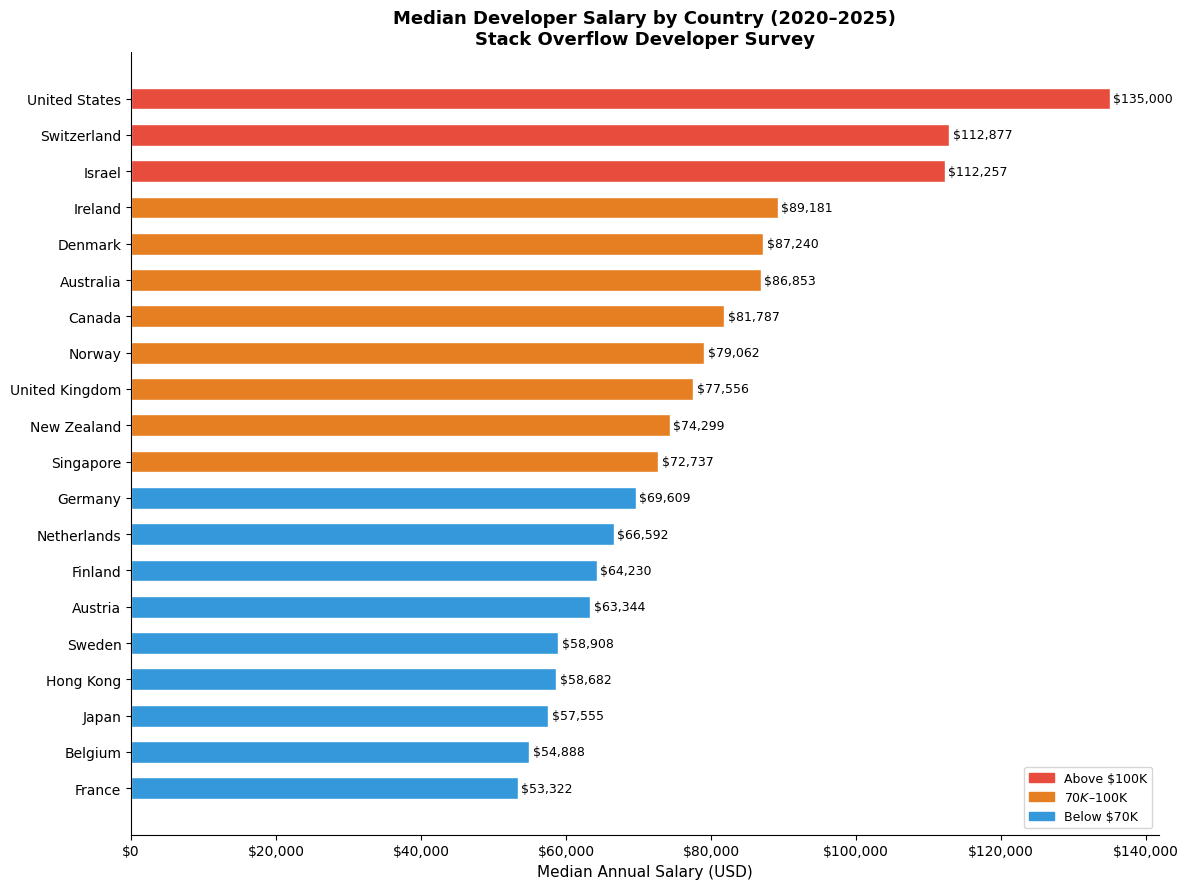

Chart saved.


In [23]:
# ============================================================
# CELL 20 — Visualize Salary by Country
# ============================================================

top_countries = country_salary.head(20)

countries = top_countries['country'].to_list()[::-1]
salaries  = top_countries['median_salary'].to_list()[::-1]

fig, ax = plt.subplots(figsize=(12, 9))

colors = ['#e74c3c' if s >= 100000 else '#e67e22' if s >= 70000 else '#3498db' for s in salaries]

bars = ax.barh(countries, salaries, color=colors, edgecolor='white', height=0.6)

for bar, val in zip(bars, salaries):
    ax.text(
        bar.get_width() + 500,
        bar.get_y() + bar.get_height() / 2,
        f'${val:,.0f}',
        va='center',
        fontsize=9
    )

ax.set_xlabel('Median Annual Salary (USD)', fontsize=11)
ax.set_title('Median Developer Salary by Country (2020–2025)\nStack Overflow Developer Survey', fontsize=13, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${int(x):,}'))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

from matplotlib.patches import Patch
legend = [
    Patch(color='#e74c3c', label='Above $100K'),
    Patch(color='#e67e22', label='$70K–$100K'),
    Patch(color='#3498db', label='Below $70K')
]
ax.legend(handles=legend, loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/developer_career_intelligence/exports/salary_by_country.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved.")

In [24]:
# ============================================================
# CELL 21 — Check India and Other Major Countries
# ============================================================

# Check specific countries we expect to see
check_countries = ['India', 'Brazil', 'China', 'Nigeria', 'Pakistan', 'Mexico']

india_check = (
    salary_df
    .filter(pl.col('country').is_in(check_countries))
    .group_by('country')
    .agg([
        pl.col('salary_usd').median().alias('median_salary'),
        pl.col('salary_usd').mean().alias('mean_salary'),
        pl.col('salary_usd').count().alias('count')
    ])
    .sort('median_salary', descending=True)
)

print(f"{'Country':<15} {'Median Salary':>15} {'Mean Salary':>13} {'Responses':>10}")
print("-" * 57)

for row in india_check.iter_rows():
    print(f"{row[0]:<15} ${row[1]:>13,.0f} ${row[2]:>11,.0f} {row[3]:>10,}")

# Also check India's global rank
total_countries = country_salary.shape[0]
india_rank = None

for i, row in enumerate(country_salary.iter_rows(), 1):
    if row[0] == 'India':
        india_rank = i
        india_salary = row[1]
        india_count = row[2]
        break

if india_rank:
    print(f"\nIndia's global salary rank : {india_rank} out of {total_countries} countries")
    print(f"India median salary        : ${india_salary:,.0f}")
    print(f"India responses            : {india_count:,}")
else:
    print("\nIndia not found — checking raw data...")
    # Check if India exists in master_df at all
    india_raw = master_df.filter(pl.col('country') == 'India').shape[0]
    print(f"India rows in master dataset : {india_raw:,}")

Country           Median Salary   Mean Salary  Responses
---------------------------------------------------------
China           $       41,270 $     52,905        886
Mexico          $       25,860 $     35,529      1,754
Brazil          $       24,616 $     35,102      6,495
India           $       15,201 $     27,738     12,360
Nigeria         $        9,685 $     18,908        687
Pakistan        $        7,776 $     14,742      1,411

India's global salary rank : 57 out of 67 countries
India median salary        : $15,201
India responses            : 12,360


In [25]:
# ============================================================
# CELL 22 — Salary by Education Level
# ============================================================

ed_salary = (
    salary_df
    .filter(pl.col('ed_level').is_not_null())
    .group_by('ed_level')
    .agg([
        pl.col('salary_usd').median().alias('median_salary'),
        pl.col('salary_usd').count().alias('count')
    ])
    .filter(pl.col('count') >= 200)
    .sort('median_salary', descending=True)
)

print("Median Salary by Education Level\n")
print(f"{'Rank':<5} {'Education Level':<60} {'Median Salary':>15} {'Responses':>10}")
print("-" * 93)

for i, row in enumerate(ed_salary.iter_rows(), 1):
    print(f"{i:<5} {row[0]:<60} ${row[1]:>13,.0f} {row[2]:>10,}")

Median Salary by Education Level

Rank  Education Level                                                Median Salary  Responses
---------------------------------------------------------------------------------------------
1     Professional degree (JD, MD, Ph.D, Ed.D, etc.)               $       83,000      4,676
2     Other doctoral degree (Ph.D., Ed.D., etc.)                   $       75,669      4,009
3     Master’s degree (M.A., M.S., M.Eng., MBA, etc.)              $       67,845     55,439
4     Bachelor’s degree (B.A., B.S., B.Eng., etc.)                 $       65,000     97,223
5     Associate degree (A.A., A.S., etc.)                          $       63,986      6,748
6     Some college/university study without earning a degree       $       59,586     24,734
7     Primary/elementary school                                    $       53,392      1,028
8     Something else                                               $       52,912      1,486
9     Secondary school (e.g. Ameri

In [26]:
# ============================================================
# CELL 23 — Fix Education Level Inconsistencies
# ============================================================

ed_fix = {
    'Professional degree (JD, MD, Ph.D, Ed.D, etc.)' : 'Professional degree (JD, MD, etc.)',
    'Other doctoral degree (Ph.D., Ed.D., etc.)'      : 'Doctoral degree (Ph.D., Ed.D., etc.)',
    'Master\u2019s degree (M.A., M.S., M.Eng., MBA, etc.)' : "Master's degree",
    "Master's degree (M.A., M.S., M.Eng., MBA, etc.)" : "Master's degree",
    'Bachelor\u2019s degree (B.A., B.S., B.Eng., etc.)' : "Bachelor's degree",
    "Bachelor's degree (B.A., B.S., B.Eng., etc.)"   : "Bachelor's degree",
    'Associate degree (A.A., A.S., etc.)'             : 'Associate degree',
    'Some college/university study without earning a degree' : 'Some college, no degree',
    'Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)' : 'Secondary school',
    'Primary/elementary school'                       : 'Primary school',
}

# Apply fix to both dataframes
salary_df = salary_df.with_columns(
    pl.col('ed_level').replace(ed_fix).alias('ed_level')
)

master_df = master_df.with_columns(
    pl.col('ed_level').replace(ed_fix).alias('ed_level')
)

# Recalculate after fix
ed_salary = (
    salary_df
    .filter(pl.col('ed_level').is_not_null())
    .group_by('ed_level')
    .agg([
        pl.col('salary_usd').median().alias('median_salary'),
        pl.col('salary_usd').count().alias('count')
    ])
    .filter(pl.col('count') >= 200)
    .sort('median_salary', descending=True)
)

print("Median Salary by Education Level (After Fix)\n")
print(f"{'Rank':<5} {'Education Level':<45} {'Median Salary':>15} {'Responses':>10}")
print("-" * 78)

for i, row in enumerate(ed_salary.iter_rows(), 1):
    print(f"{i:<5} {row[0]:<45} ${row[1]:>13,.0f} {row[2]:>10,}")

Median Salary by Education Level (After Fix)

Rank  Education Level                                 Median Salary  Responses
------------------------------------------------------------------------------
1     Doctoral degree (Ph.D., Ed.D., etc.)          $       75,669      4,009
2     Professional degree (JD, MD, etc.)            $       70,000      6,519
3     Master's degree                               $       67,845     55,439
4     Bachelor's degree                             $       65,000     97,223
5     Associate degree                              $       63,986      6,748
6     Some college, no degree                       $       59,586     24,734
7     Primary school                                $       53,392      1,028
8     Something else                                $       52,912      1,486
9     Secondary school                              $       48,590      9,504


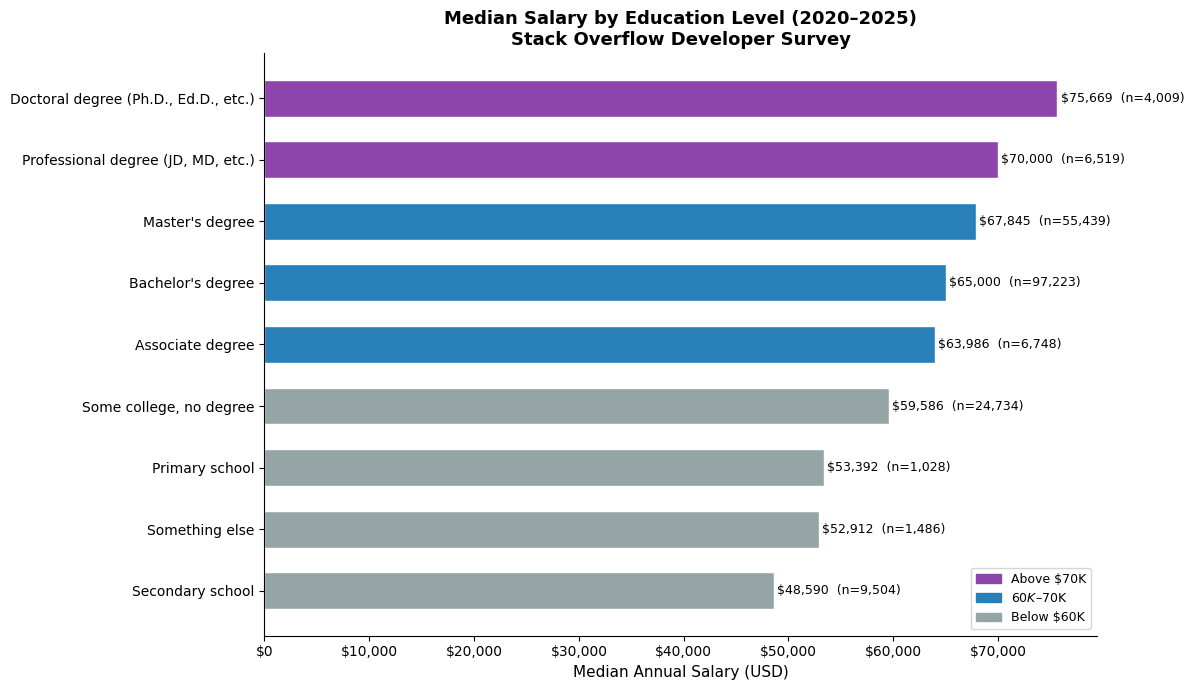

Chart saved.


In [27]:
# ============================================================
# CELL 24 — Visualize Salary by Education Level
# ============================================================

ed_list     = ed_salary['ed_level'].to_list()[::-1]
sal_list    = ed_salary['median_salary'].to_list()[::-1]
count_list  = ed_salary['count'].to_list()[::-1]

fig, ax = plt.subplots(figsize=(12, 7))

colors = ['#8e44ad' if s >= 70000 else '#2980b9' if s >= 60000 else '#95a5a6' for s in sal_list]

bars = ax.barh(ed_list, sal_list, color=colors, edgecolor='white', height=0.6)

for bar, val, cnt in zip(bars, sal_list, count_list):
    ax.text(
        bar.get_width() + 300,
        bar.get_y() + bar.get_height() / 2,
        f'${val:,.0f}  (n={cnt:,})',
        va='center',
        fontsize=9
    )

ax.set_xlabel('Median Annual Salary (USD)', fontsize=11)
ax.set_title('Median Salary by Education Level (2020–2025)\nStack Overflow Developer Survey', fontsize=13, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${int(x):,}'))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

from matplotlib.patches import Patch
legend = [
    Patch(color='#8e44ad', label='Above $70K'),
    Patch(color='#2980b9', label='$60K–$70K'),
    Patch(color='#95a5a6', label='Below $60K')
]
ax.legend(handles=legend, loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/developer_career_intelligence/exports/salary_by_education.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved.")

In [28]:
# ============================================================
# CELL 25 — Experience Analysis
# ============================================================

# Clean years_code_pro column
# It contains values like "1", "5", "More than 50 years", "Less than 1 year"
# We need to convert these to numbers

exp_df = salary_df.with_columns(
    pl.col('years_code_pro')
    .str.replace('More than 50 years', '51')
    .str.replace('Less than 1 year', '0')
    .cast(pl.Float64, strict=False)
    .alias('experience')
)

# Remove nulls and unrealistic values
exp_df = exp_df.filter(
    pl.col('experience').is_not_null() &
    (pl.col('experience') >= 0) &
    (pl.col('experience') <= 50)
)

# Create experience bands
exp_df = exp_df.with_columns(
    pl.when(pl.col('experience') < 1)
    .then(pl.lit('Less than 1 year'))
    .when(pl.col('experience') < 3)
    .then(pl.lit('1-2 years'))
    .when(pl.col('experience') < 6)
    .then(pl.lit('3-5 years'))
    .when(pl.col('experience') < 11)
    .then(pl.lit('6-10 years'))
    .when(pl.col('experience') < 21)
    .then(pl.lit('11-20 years'))
    .otherwise(pl.lit('20+ years'))
    .alias('experience_band')
)

# Aggregate by experience band
exp_salary = (
    exp_df
    .group_by('experience_band')
    .agg([
        pl.col('salary_usd').median().alias('median_salary'),
        pl.col('salary_usd').count().alias('count')
    ])
    .sort('median_salary', descending=True)
)

# Define correct order for display
band_order = ['Less than 1 year', '1-2 years', '3-5 years', '6-10 years', '11-20 years', '20+ years']

exp_salary = exp_salary.with_columns(
    pl.col('experience_band')
    .cast(pl.Enum(band_order))
    .alias('experience_band')
).sort('experience_band')

print("Median Salary by Experience Level\n")
print(f"{'Experience':<20} {'Median Salary':>15} {'Responses':>10}")
print("-" * 48)

for row in exp_salary.iter_rows():
    print(f"{row[0]:<20} ${row[1]:>13,.0f} {row[2]:>10,}")

Median Salary by Experience Level

Experience             Median Salary  Responses
------------------------------------------------
Less than 1 year     $       25,896      6,323
1-2 years            $       30,521     25,128
3-5 years            $       47,115     47,610
6-10 years           $       69,102     54,492
11-20 years          $       86,478     47,764
20+ years            $      107,000     24,801


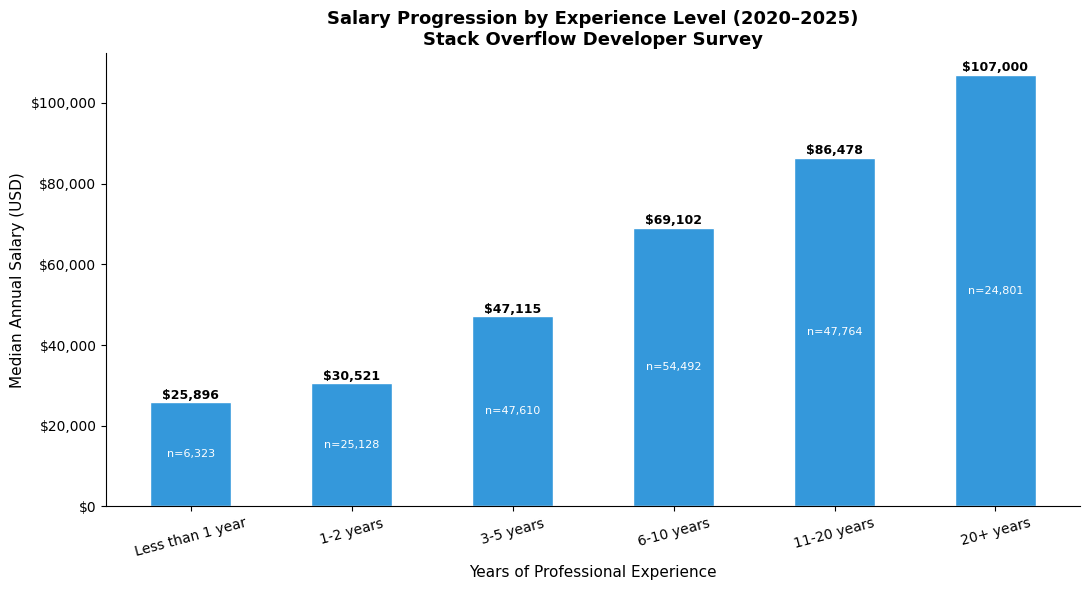

Chart saved.


In [29]:
# ============================================================
# CELL 26 — Visualize Experience vs Salary
# ============================================================

bands    = exp_salary['experience_band'].to_list()
salaries = exp_salary['median_salary'].to_list()
counts   = exp_salary['count'].to_list()

fig, ax1 = plt.subplots(figsize=(11, 6))

# Bar chart for salary
colors = ['#3498db'] * len(bands)
bars = ax1.bar(bands, salaries, color=colors, edgecolor='white', width=0.5)

# Add salary labels on top of bars
for bar, val in zip(bars, salaries):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 800,
        f'${val:,.0f}',
        ha='center',
        fontsize=9,
        fontweight='bold'
    )

# Add count labels inside bars
for bar, cnt in zip(bars, counts):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() / 2,
        f'n={cnt:,}',
        ha='center',
        va='center',
        fontsize=8,
        color='white'
    )

ax1.set_xlabel('Years of Professional Experience', fontsize=11)
ax1.set_ylabel('Median Annual Salary (USD)', fontsize=11)
ax1.set_title('Salary Progression by Experience Level (2020–2025)\nStack Overflow Developer Survey', fontsize=13, fontweight='bold')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${int(x):,}'))
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/developer_career_intelligence/exports/salary_by_experience.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved.")

In [30]:
# ============================================================
# CELL 27 — Top Programming Languages Per Year
# ============================================================

# Languages column contains semicolon separated values like
# "Python;JavaScript;SQL;TypeScript"
# We explode them and count per year

lang_df = (
    master_df
    .filter(pl.col('language_worked_with').is_not_null())
    .select(['survey_year', 'language_worked_with'])
    .with_columns(
        pl.col('language_worked_with').str.split(';').alias('language_worked_with')
    )
    .explode('language_worked_with')
    .with_columns(
        pl.col('language_worked_with').str.strip_chars().alias('language')
    )
    .filter(pl.col('language') != '')
)

# Count respondents per year to calculate percentages
yearly_respondents = (
    master_df
    .filter(pl.col('language_worked_with').is_not_null())
    .group_by('survey_year')
    .agg(pl.len().alias('total_respondents'))
)

# Count each language per year
lang_counts = (
    lang_df
    .group_by(['survey_year', 'language'])
    .agg(pl.len().alias('count'))
    .join(yearly_respondents, on='survey_year')
    .with_columns(
        (pl.col('count') / pl.col('total_respondents') * 100)
        .round(1)
        .alias('pct')
    )
    .sort(['survey_year', 'count'], descending=[False, True])
)

# Show top 10 languages for each year
print("Top 10 Programming Languages Per Year (% of respondents)\n")

for year in [2020, 2021, 2022, 2023, 2024, 2025]:
    year_data = lang_counts.filter(pl.col('survey_year') == year).head(10)
    print(f"--- {year} ---")
    for row in year_data.iter_rows():
        bar = '█' * int(row[4] / 2)
        print(f"  {row[1]:<25} {row[4]:>5}%  {bar}")
    print()

Top 10 Programming Languages Per Year (% of respondents)

--- 2020 ---
  JavaScript                 67.7%  █████████████████████████████████
  HTML/CSS                   63.1%  ███████████████████████████████
  SQL                        54.7%  ███████████████████████████
  Python                     44.1%  ██████████████████████
  Java                       40.2%  ████████████████████
  Bash/Shell/PowerShell      33.1%  ████████████████
  C#                         31.4%  ███████████████
  PHP                        26.2%  █████████████
  TypeScript                 25.4%  ████████████
  C++                        23.9%  ███████████

--- 2021 ---
  JavaScript                 65.1%  ████████████████████████████████
  HTML/CSS                   56.2%  ████████████████████████████
  Python                     48.3%  ████████████████████████
  SQL                        47.2%  ███████████████████████
  Java                       35.4%  █████████████████
  Node.js                    34.0%  

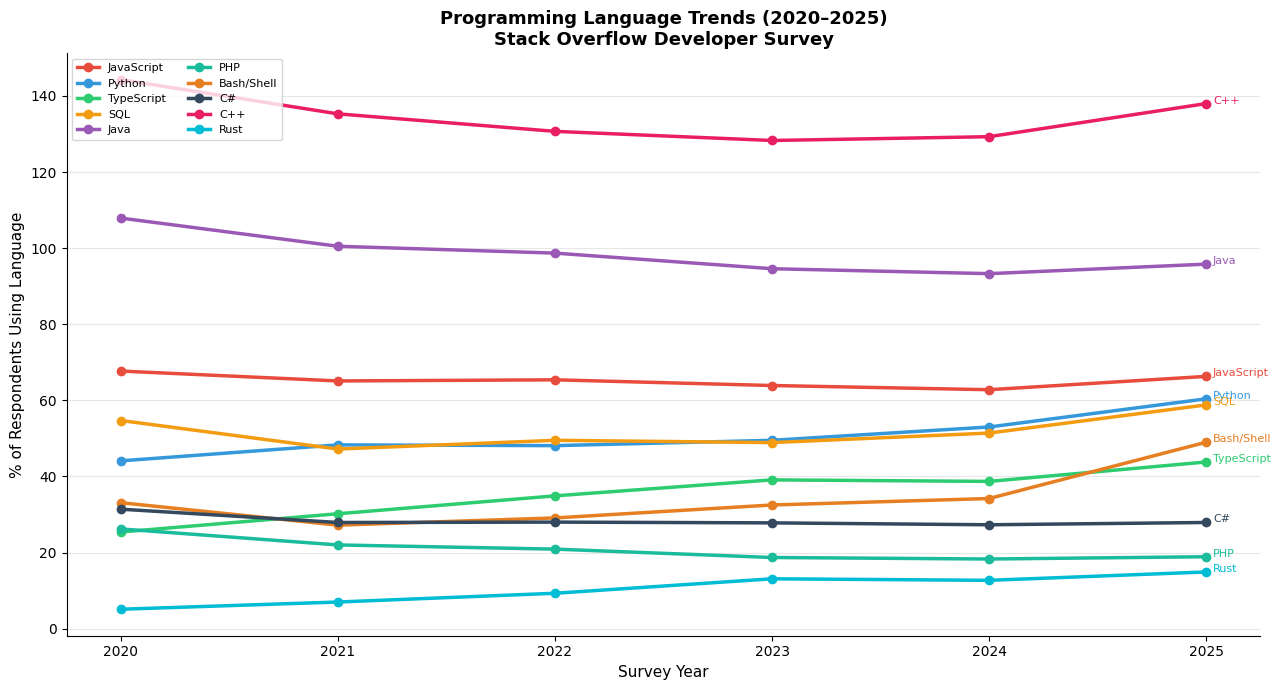

Chart saved.


In [31]:
# ============================================================
# CELL 28 — Language Trends Over Time
# ============================================================

# Track these specific languages across all years
track_languages = [
    'JavaScript', 'Python', 'TypeScript',
    'SQL', 'Java', 'PHP', 'Bash/Shell',
    'C#', 'C++', 'Rust'
]

# Build trend data for each language
trend_data = {}

for lang in track_languages:
    yearly = (
        lang_counts
        .filter(pl.col('language').str.contains(lang))
        .group_by('survey_year')
        .agg(pl.col('pct').sum().alias('pct'))
        .sort('survey_year')
    )
    if yearly.shape[0] > 0:
        trend_data[lang] = {
            'years'  : yearly['survey_year'].to_list(),
            'pct'    : yearly['pct'].to_list()
        }

# Plot
fig, ax = plt.subplots(figsize=(13, 7))

colors = [
    '#e74c3c', '#3498db', '#2ecc71',
    '#f39c12', '#9b59b6', '#1abc9c',
    '#e67e22', '#34495e', '#e91e63', '#00bcd4'
]

for i, (lang, data) in enumerate(trend_data.items()):
    ax.plot(
        data['years'],
        data['pct'],
        marker='o',
        linewidth=2.5,
        markersize=6,
        label=lang,
        color=colors[i % len(colors)]
    )
    # Add label at end of line
    if data['years']:
        ax.annotate(
            lang,
            xy=(data['years'][-1], data['pct'][-1]),
            xytext=(5, 0),
            textcoords='offset points',
            fontsize=8,
            color=colors[i % len(colors)]
        )

ax.set_xlabel('Survey Year', fontsize=11)
ax.set_ylabel('% of Respondents Using Language', fontsize=11)
ax.set_title('Programming Language Trends (2020–2025)\nStack Overflow Developer Survey', fontsize=13, fontweight='bold')
ax.set_xticks([2020, 2021, 2022, 2023, 2024, 2025])
ax.legend(loc='upper left', fontsize=8, ncol=2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/developer_career_intelligence/exports/language_trends.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved.")

In [32]:
# ============================================================
# CELL 29 — Top Databases Per Year
# ============================================================

db_df = (
    master_df
    .filter(pl.col('database_worked_with').is_not_null())
    .select(['survey_year', 'database_worked_with'])
    .with_columns(
        pl.col('database_worked_with').str.split(';').alias('database_worked_with')
    )
    .explode('database_worked_with')
    .with_columns(
        pl.col('database_worked_with').str.strip_chars().alias('database')
    )
    .filter(pl.col('database') != '')
)

yearly_db_respondents = (
    master_df
    .filter(pl.col('database_worked_with').is_not_null())
    .group_by('survey_year')
    .agg(pl.len().alias('total_respondents'))
)

db_counts = (
    db_df
    .group_by(['survey_year', 'database'])
    .agg(pl.len().alias('count'))
    .join(yearly_db_respondents, on='survey_year')
    .with_columns(
        (pl.col('count') / pl.col('total_respondents') * 100)
        .round(1)
        .alias('pct')
    )
    .sort(['survey_year', 'count'], descending=[False, True])
)

print("Top 10 Databases Per Year (% of respondents)\n")

for year in [2020, 2021, 2022, 2023, 2024, 2025]:
    year_data = db_counts.filter(pl.col('survey_year') == year).head(10)
    print(f"--- {year} ---")
    for row in year_data.iter_rows():
        bar = '█' * int(row[4] / 2)
        print(f"  {row[1]:<30} {row[4]:>5}%  {bar}")
    print()


Top 10 Databases Per Year (% of respondents)

--- 2020 ---
  MySQL                           55.6%  ███████████████████████████
  PostgreSQL                      36.1%  ██████████████████
  Microsoft SQL Server            33.0%  ████████████████
  SQLite                          31.2%  ███████████████
  MongoDB                         26.4%  █████████████
  Redis                           18.3%  █████████
  MariaDB                         16.8%  ████████
  Oracle                          16.5%  ████████
  Firebase                        14.4%  ███████
  Elasticsearch                   13.8%  ██████

--- 2021 ---
  MySQL                           50.7%  █████████████████████████
  PostgreSQL                      40.9%  ████████████████████
  SQLite                          32.5%  ████████████████
  MongoDB                         28.0%  ██████████████
  Microsoft SQL Server            27.2%  █████████████
  Redis                           20.9%  ██████████
  MariaDB                     

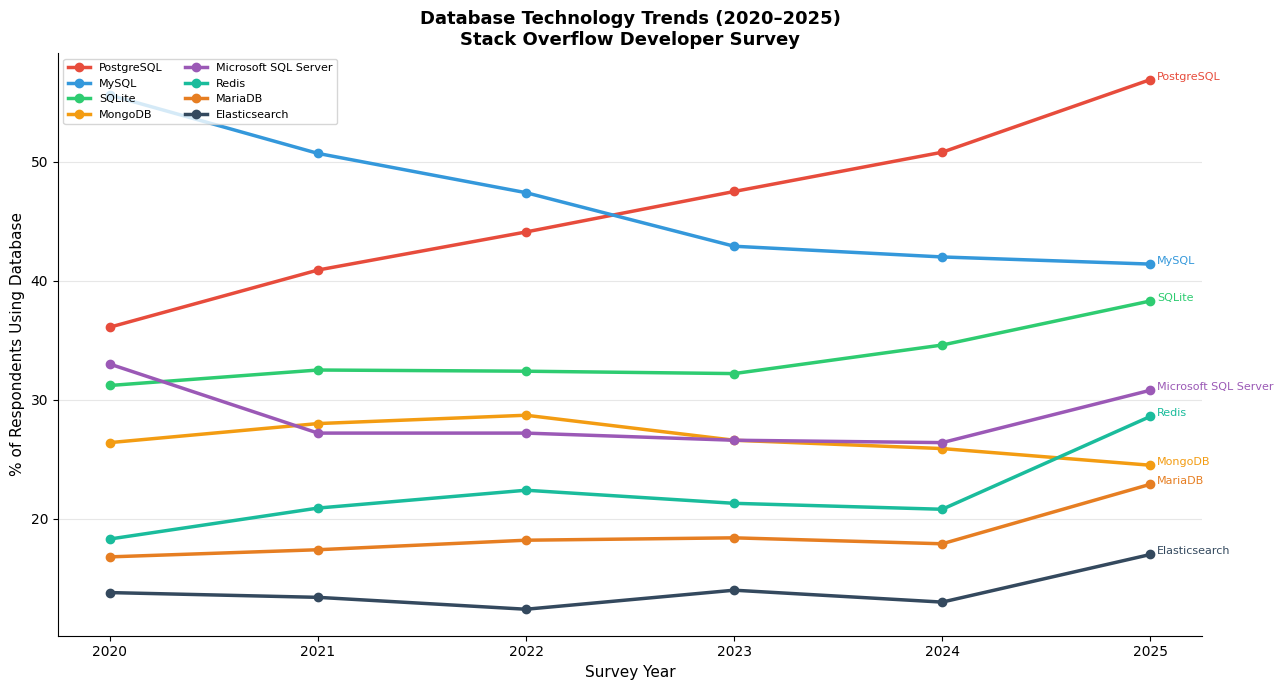

Chart saved.


In [33]:
# ============================================================
# CELL 32 — Database Trends Over Time
# ============================================================

track_databases = [
    'PostgreSQL', 'MySQL', 'SQLite',
    'MongoDB', 'Microsoft SQL Server',
    'Redis', 'MariaDB', 'Elasticsearch'
]

db_trend_data = {}

for db in track_databases:
    yearly = (
        db_counts
        .filter(pl.col('database').str.contains(db))
        .group_by('survey_year')
        .agg(pl.col('pct').sum().alias('pct'))
        .sort('survey_year')
    )
    if yearly.shape[0] > 0:
        db_trend_data[db] = {
            'years' : yearly['survey_year'].to_list(),
            'pct'   : yearly['pct'].to_list()
        }

colors = [
    '#e74c3c', '#3498db', '#2ecc71',
    '#f39c12', '#9b59b6', '#1abc9c',
    '#e67e22', '#34495e'
]

fig, ax = plt.subplots(figsize=(13, 7))

for i, (db, data) in enumerate(db_trend_data.items()):
    ax.plot(
        data['years'],
        data['pct'],
        marker='o',
        linewidth=2.5,
        markersize=6,
        label=db,
        color=colors[i % len(colors)]
    )
    if data['years']:
        ax.annotate(
            db,
            xy=(data['years'][-1], data['pct'][-1]),
            xytext=(5, 0),
            textcoords='offset points',
            fontsize=8,
            color=colors[i % len(colors)]
        )

ax.set_xlabel('Survey Year', fontsize=11)
ax.set_ylabel('% of Respondents Using Database', fontsize=11)
ax.set_title('Database Technology Trends (2020–2025)\nStack Overflow Developer Survey', fontsize=13, fontweight='bold')
ax.set_xticks([2020, 2021, 2022, 2023, 2024, 2025])
ax.legend(loc='upper left', fontsize=8, ncol=2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/developer_career_intelligence/exports/database_trends.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved.")

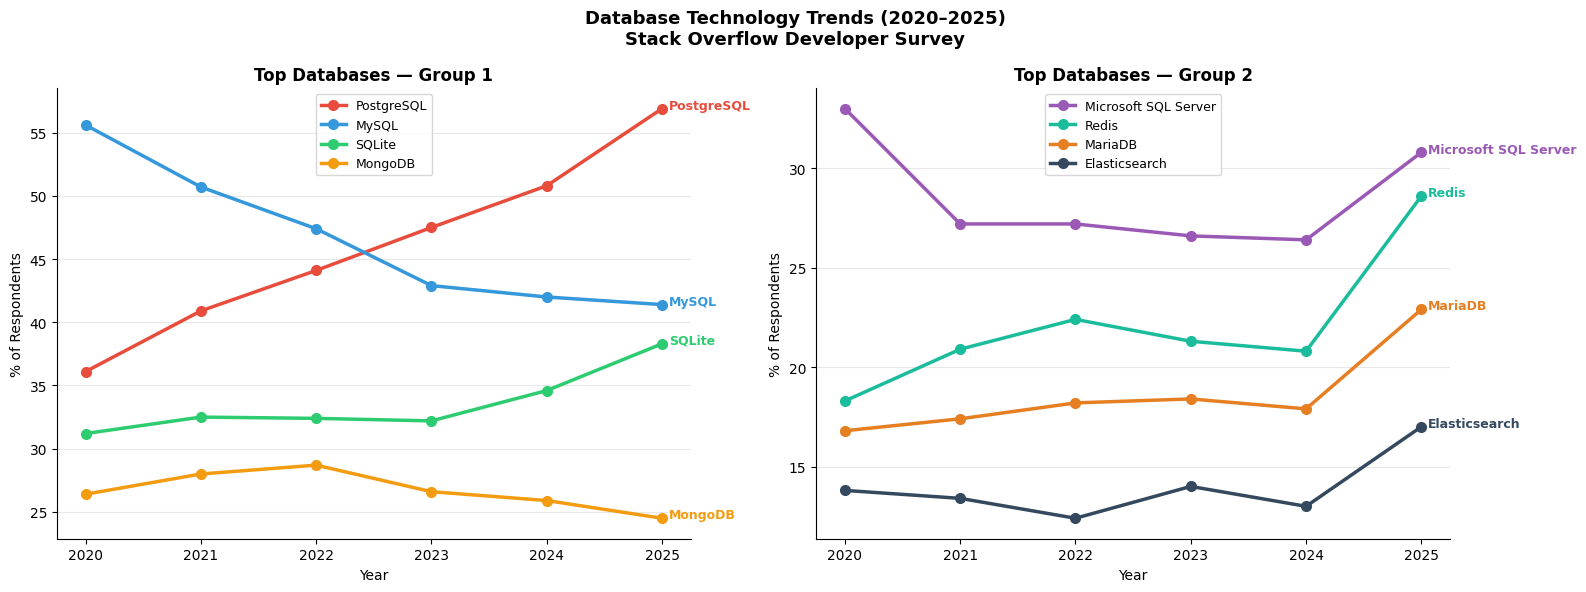

Chart saved.


In [34]:
# ============================================================
# CELL 32 — Database Trends — Two Clean Charts
# ============================================================

track_databases = [
    'PostgreSQL', 'MySQL', 'SQLite',
    'MongoDB', 'Microsoft SQL Server',
    'Redis', 'MariaDB', 'Elasticsearch'
]

db_trend_data = {}
for db in track_databases:
    yearly = (
        db_counts
        .filter(pl.col('database').str.contains(db))
        .group_by('survey_year')
        .agg(pl.col('pct').sum().alias('pct'))
        .sort('survey_year')
    )
    if yearly.shape[0] > 0:
        db_trend_data[db] = {
            'years' : yearly['survey_year'].to_list(),
            'pct'   : yearly['pct'].to_list()
        }

# Split into top 4 and next 4
db_names  = list(db_trend_data.keys())
group1    = db_names[:4]   # PostgreSQL, MySQL, SQLite, MongoDB
group2    = db_names[4:]   # MSSQL, Redis, MariaDB, Elasticsearch

colors_g1 = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']
colors_g2 = ['#9b59b6', '#1abc9c', '#e67e22', '#34495e']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- Chart 1 ---
for i, db in enumerate(group1):
    data = db_trend_data[db]
    ax1.plot(data['years'], data['pct'], marker='o', linewidth=2.5,
             markersize=7, label=db, color=colors_g1[i])
    ax1.annotate(db,
        xy=(data['years'][-1], data['pct'][-1]),
        xytext=(5, 0), textcoords='offset points',
        fontsize=9, color=colors_g1[i], fontweight='bold')

ax1.set_title('Top Databases — Group 1', fontsize=12, fontweight='bold')
ax1.set_xlabel('Year', fontsize=10)
ax1.set_ylabel('% of Respondents', fontsize=10)
ax1.set_xticks([2020, 2021, 2022, 2023, 2024, 2025])
ax1.legend(fontsize=9)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.grid(axis='y', alpha=0.3)

# --- Chart 2 ---
for i, db in enumerate(group2):
    data = db_trend_data[db]
    ax2.plot(data['years'], data['pct'], marker='o', linewidth=2.5,
             markersize=7, label=db, color=colors_g2[i])
    ax2.annotate(db,
        xy=(data['years'][-1], data['pct'][-1]),
        xytext=(5, 0), textcoords='offset points',
        fontsize=9, color=colors_g2[i], fontweight='bold')

ax2.set_title('Top Databases — Group 2', fontsize=12, fontweight='bold')
ax2.set_xlabel('Year', fontsize=10)
ax2.set_ylabel('% of Respondents', fontsize=10)
ax2.set_xticks([2020, 2021, 2022, 2023, 2024, 2025])
ax2.legend(fontsize=9)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.grid(axis='y', alpha=0.3)

fig.suptitle('Database Technology Trends (2020–2025)\nStack Overflow Developer Survey',
             fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/developer_career_intelligence/exports/database_trends.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved.")

In [35]:
# ============================================================
# CELL 30 — Top Cloud Platforms Per Year
# ============================================================

platform_df = (
    master_df
    .filter(pl.col('platform_worked_with').is_not_null())
    .select(['survey_year', 'platform_worked_with'])
    .with_columns(
        pl.col('platform_worked_with').str.split(';').alias('platform_worked_with')
    )
    .explode('platform_worked_with')
    .with_columns(
        pl.col('platform_worked_with').str.strip_chars().alias('platform')
    )
    .filter(pl.col('platform') != '')
)

yearly_platform_respondents = (
    master_df
    .filter(pl.col('platform_worked_with').is_not_null())
    .group_by('survey_year')
    .agg(pl.len().alias('total_respondents'))
)

platform_counts = (
    platform_df
    .group_by(['survey_year', 'platform'])
    .agg(pl.len().alias('count'))
    .join(yearly_platform_respondents, on='survey_year')
    .with_columns(
        (pl.col('count') / pl.col('total_respondents') * 100)
        .round(1)
        .alias('pct')
    )
    .sort(['survey_year', 'count'], descending=[False, True])
)

print("Top 10 Cloud Platforms Per Year (% of respondents)\n")

for year in [2020, 2021, 2022, 2023, 2024, 2025]:
    year_data = platform_counts.filter(pl.col('survey_year') == year).head(10)
    print(f"--- {year} ---")
    for row in year_data.iter_rows():
        bar = '█' * int(row[4] / 2)
        print(f"  {row[1]:<35} {row[4]:>5}%  {bar}")
    print()

Top 10 Cloud Platforms Per Year (% of respondents)

--- 2020 ---
  Linux                                55.0%  ███████████████████████████
  Windows                              53.1%  ██████████████████████████
  Docker                               35.0%  █████████████████
  AWS                                  26.7%  █████████████
  Android                              26.2%  █████████████
  MacOS                                24.0%  ████████████
  Raspberry Pi                         14.9%  ███████
  Microsoft Azure                      14.5%  ███████
  WordPress                            14.2%  ███████
  Google Cloud Platform                14.1%  ███████

--- 2021 ---
  AWS                                  55.9%  ███████████████████████████
  Google Cloud Platform                32.0%  ████████████████
  Microsoft Azure                      31.7%  ███████████████
  Heroku                               24.7%  ████████████
  DigitalOcean                         18.2%  █████████
 

In [36]:
# ============================================================
# CELL 31 — Separate Cloud Platforms from Dev Tools
# ============================================================

# These are actual cloud providers
cloud_platforms = [
    'AWS', 'Amazon Web Services (AWS)', 'Google Cloud',
    'Google Cloud Platform', 'Microsoft Azure', 'Azure',
    'Heroku', 'DigitalOcean', 'Digital Ocean',
    'Firebase', 'IBM Cloud or Watson', 'Cloudflare',
    'Oracle Cloud Infrastructure', 'Vercel', 'Netlify',
    'Linode', 'OVH', 'VMware', 'Managed Hosting'
]

# Standardize cloud platform names
cloud_name_fix = {
    'Amazon Web Services (AWS)'  : 'AWS',
    'Google Cloud Platform'      : 'Google Cloud',
    'Microsoft Azure'            : 'Azure',
    'Digital Ocean'              : 'DigitalOcean',
}

cloud_df = (
    platform_df
    .filter(pl.col('platform').is_in(cloud_platforms))
    .with_columns(
        pl.col('platform').replace(cloud_name_fix).alias('platform')
    )
)

# Recalculate with clean cloud data only
cloud_counts = (
    cloud_df
    .group_by(['survey_year', 'platform'])
    .agg(pl.len().alias('count'))
    .join(yearly_platform_respondents, on='survey_year')
    .with_columns(
        (pl.col('count') / pl.col('total_respondents') * 100)
        .round(1)
        .alias('pct')
    )
    .sort(['survey_year', 'count'], descending=[False, True])
)

print("Top Cloud Platforms Per Year (% of respondents)\n")

for year in [2020, 2021, 2022, 2023, 2024, 2025]:
    year_data = cloud_counts.filter(pl.col('survey_year') == year).head(8)
    print(f"--- {year} ---")
    for row in year_data.iter_rows():
        bar = '█' * int(row[4] / 2)
        print(f"  {row[1]:<30} {row[4]:>5}%  {bar}")
    print()

Top Cloud Platforms Per Year (% of respondents)

--- 2020 ---
  AWS                             26.7%  █████████████
  Azure                           14.5%  ███████
  Google Cloud                    14.1%  ███████
  Heroku                          11.1%  █████
  IBM Cloud or Watson              1.6%  

--- 2021 ---
  AWS                             55.9%  ███████████████████████████
  Google Cloud                    32.0%  ████████████████
  Azure                           31.7%  ███████████████
  Heroku                          24.7%  ████████████
  DigitalOcean                    18.2%  █████████
  IBM Cloud or Watson              2.6%  █
  Oracle Cloud Infrastructure      1.9%  

--- 2022 ---
  AWS                             52.0%  ██████████████████████████
  Azure                           29.3%  ██████████████
  Google Cloud                    27.3%  █████████████
  Firebase                        21.5%  ██████████
  Heroku                          20.4%  ██████████
  DigitalOc

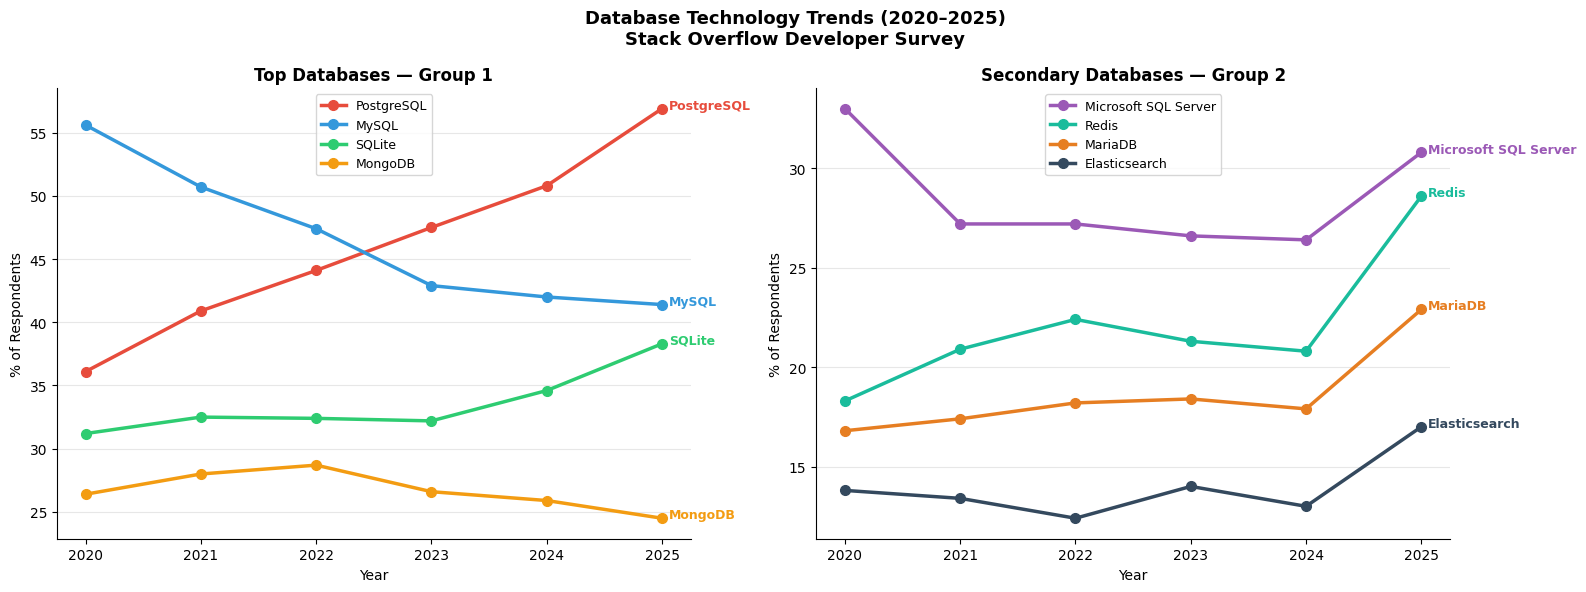

Chart saved.


In [37]:
# ============================================================
# CELL 32 — Database Technology Trends (Two Clean Charts)
# ============================================================

track_databases = [
    'PostgreSQL', 'MySQL', 'SQLite',
    'MongoDB', 'Microsoft SQL Server',
    'Redis', 'MariaDB', 'Elasticsearch'
]

db_trend_data = {}

for db in track_databases:
    yearly = (
        db_counts
        .filter(pl.col('database').str.contains(db))
        .group_by('survey_year')
        .agg(pl.col('pct').sum().alias('pct'))
        .sort('survey_year')
    )
    if yearly.shape[0] > 0:
        db_trend_data[db] = {
            'years' : yearly['survey_year'].to_list(),
            'pct'   : yearly['pct'].to_list()
        }

# Split into two groups of 4
db_names = list(db_trend_data.keys())
group1   = db_names[:4]   # PostgreSQL, MySQL, SQLite, MongoDB
group2   = db_names[4:]   # MSSQL, Redis, MariaDB, Elasticsearch

colors_g1 = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']
colors_g2 = ['#9b59b6', '#1abc9c', '#e67e22', '#34495e']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- Chart 1 ---
for i, db in enumerate(group1):
    data = db_trend_data[db]
    ax1.plot(data['years'], data['pct'], marker='o', linewidth=2.5,
             markersize=7, label=db, color=colors_g1[i])
    ax1.annotate(db,
        xy=(data['years'][-1], data['pct'][-1]),
        xytext=(5, 0), textcoords='offset points',
        fontsize=9, color=colors_g1[i], fontweight='bold')

ax1.set_title('Top Databases — Group 1', fontsize=12, fontweight='bold')
ax1.set_xlabel('Year', fontsize=10)
ax1.set_ylabel('% of Respondents', fontsize=10)
ax1.set_xticks([2020, 2021, 2022, 2023, 2024, 2025])
ax1.legend(fontsize=9)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.grid(axis='y', alpha=0.3)

# --- Chart 2 ---
for i, db in enumerate(group2):
    data = db_trend_data[db]
    ax2.plot(data['years'], data['pct'], marker='o', linewidth=2.5,
             markersize=7, label=db, color=colors_g2[i])
    ax2.annotate(db,
        xy=(data['years'][-1], data['pct'][-1]),
        xytext=(5, 0), textcoords='offset points',
        fontsize=9, color=colors_g2[i], fontweight='bold')

ax2.set_title('Secondary Databases — Group 2', fontsize=12, fontweight='bold')
ax2.set_xlabel('Year', fontsize=10)
ax2.set_ylabel('% of Respondents', fontsize=10)
ax2.set_xticks([2020, 2021, 2022, 2023, 2024, 2025])
ax2.legend(fontsize=9)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.grid(axis='y', alpha=0.3)

fig.suptitle('Database Technology Trends (2020–2025)\nStack Overflow Developer Survey',
             fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/developer_career_intelligence/exports/database_trends.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved.")

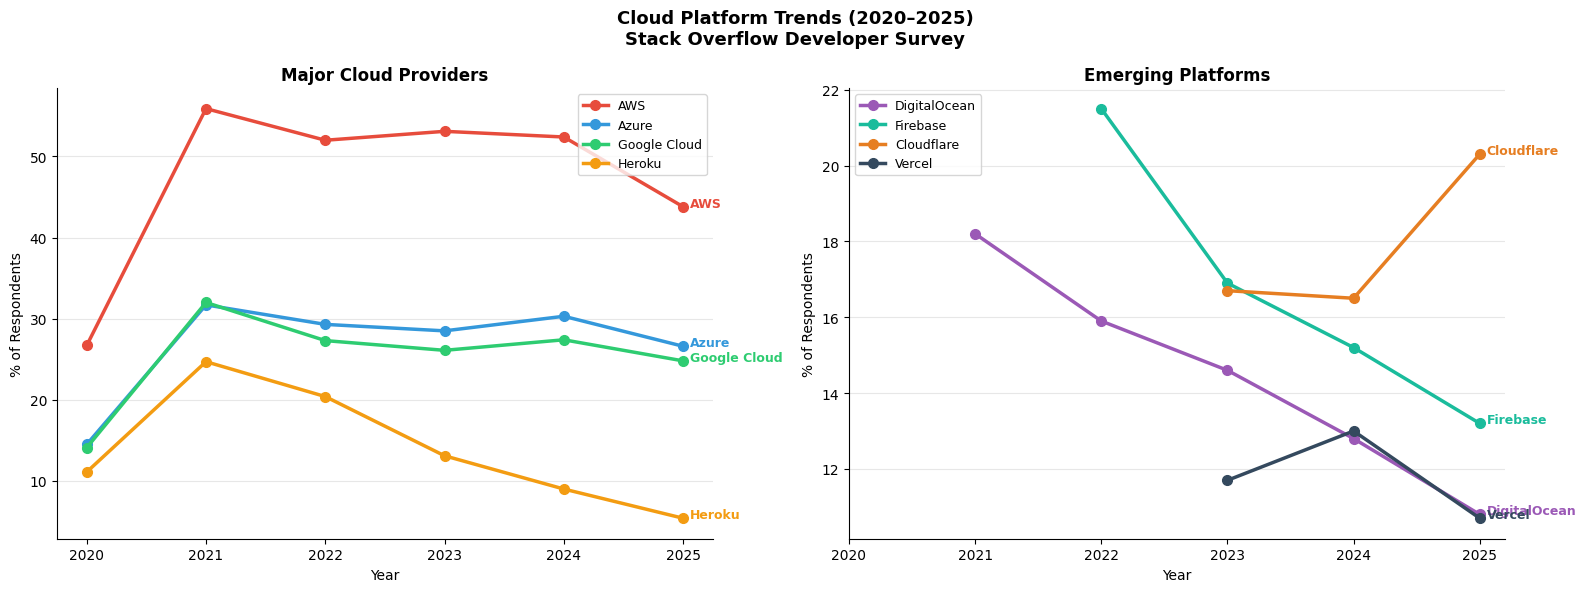

Chart saved.


In [38]:
# ============================================================
# CELL 33 — Cloud Platform Trends (Two Clean Charts)
# ============================================================

track_clouds = [
    'AWS', 'Azure', 'Google Cloud',
    'Heroku', 'DigitalOcean', 'Firebase',
    'Cloudflare', 'Vercel'
]

cloud_trend_data = {}

for cloud in track_clouds:
    yearly = (
        cloud_counts
        .filter(pl.col('platform').str.contains(cloud))
        .group_by('survey_year')
        .agg(pl.col('pct').sum().alias('pct'))
        .sort('survey_year')
    )
    if yearly.shape[0] > 0:
        cloud_trend_data[cloud] = {
            'years' : yearly['survey_year'].to_list(),
            'pct'   : yearly['pct'].to_list()
        }

cloud_names = list(cloud_trend_data.keys())
group1 = cloud_names[:4]   # AWS, Azure, Google Cloud, Heroku
group2 = cloud_names[4:]   # DigitalOcean, Firebase, Cloudflare, Vercel

colors_g1 = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']
colors_g2 = ['#9b59b6', '#1abc9c', '#e67e22', '#34495e']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- Chart 1 — Major Providers ---
for i, cloud in enumerate(group1):
    data = cloud_trend_data[cloud]
    ax1.plot(data['years'], data['pct'], marker='o', linewidth=2.5,
             markersize=7, label=cloud, color=colors_g1[i])
    ax1.annotate(cloud,
        xy=(data['years'][-1], data['pct'][-1]),
        xytext=(5, 0), textcoords='offset points',
        fontsize=9, color=colors_g1[i], fontweight='bold')

ax1.set_title('Major Cloud Providers', fontsize=12, fontweight='bold')
ax1.set_xlabel('Year', fontsize=10)
ax1.set_ylabel('% of Respondents', fontsize=10)
ax1.set_xticks([2020, 2021, 2022, 2023, 2024, 2025])
ax1.legend(fontsize=9)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.grid(axis='y', alpha=0.3)

# --- Chart 2 — Emerging Platforms ---
for i, cloud in enumerate(group2):
    data = cloud_trend_data[cloud]
    ax2.plot(data['years'], data['pct'], marker='o', linewidth=2.5,
             markersize=7, label=cloud, color=colors_g2[i])
    ax2.annotate(cloud,
        xy=(data['years'][-1], data['pct'][-1]),
        xytext=(5, 0), textcoords='offset points',
        fontsize=9, color=colors_g2[i], fontweight='bold')

ax2.set_title('Emerging Platforms', fontsize=12, fontweight='bold')
ax2.set_xlabel('Year', fontsize=10)
ax2.set_ylabel('% of Respondents', fontsize=10)
ax2.set_xticks([2020, 2021, 2022, 2023, 2024, 2025])
ax2.legend(fontsize=9)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.grid(axis='y', alpha=0.3)

fig.suptitle('Cloud Platform Trends (2020–2025)\nStack Overflow Developer Survey',
             fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/developer_career_intelligence/exports/cloud_trends.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved.")

In [39]:
###################################################################

In [40]:
# ============================================================
# CELL 34 — Top Web Frameworks Per Year
# ============================================================

web_df = (
    master_df
    .filter(pl.col('webframe_worked_with').is_not_null())
    .select(['survey_year', 'webframe_worked_with'])
    .with_columns(
        pl.col('webframe_worked_with').str.split(';').alias('webframe_worked_with')
    )
    .explode('webframe_worked_with')
    .with_columns(
        pl.col('webframe_worked_with').str.strip_chars().alias('framework')
    )
    .filter(pl.col('framework') != '')
)

yearly_web_respondents = (
    master_df
    .filter(pl.col('webframe_worked_with').is_not_null())
    .group_by('survey_year')
    .agg(pl.len().alias('total_respondents'))
)

web_counts = (
    web_df
    .group_by(['survey_year', 'framework'])
    .agg(pl.len().alias('count'))
    .join(yearly_web_respondents, on='survey_year')
    .with_columns(
        (pl.col('count') / pl.col('total_respondents') * 100)
        .round(1)
        .alias('pct')
    )
    .sort(['survey_year', 'count'], descending=[False, True])
)

print("Top 10 Web Frameworks Per Year (% of respondents)\n")

for year in [2020, 2021, 2022, 2023, 2024, 2025]:
    year_data = web_counts.filter(pl.col('survey_year') == year).head(10)
    print(f"--- {year} ---")
    for row in year_data.iter_rows():
        bar = '█' * int(row[4] / 2)
        print(f"  {row[1]:<30} {row[4]:>5}%  {bar}")
    print()

Top 10 Web Frameworks Per Year (% of respondents)

--- 2020 ---
  jQuery                          43.3%  █████████████████████
  React.js                        35.9%  █████████████████
  Angular                         25.1%  ████████████
  ASP.NET                         21.9%  ██████████
  Express                         21.2%  ██████████
  ASP.NET Core                    19.1%  █████████
  Vue.js                          17.3%  ████████
  Spring                          16.4%  ████████
  Angular.js                      16.1%  ████████
  Django                          14.2%  ███████

--- 2021 ---
  React.js                        41.0%  ████████████████████
  jQuery                          35.2%  █████████████████
  Express                         24.3%  ████████████
  Angular                         23.5%  ███████████
  Vue.js                          19.4%  █████████
  ASP.NET Core                    18.5%  █████████
  Flask                           16.5%  ████████
  ASP.NET   

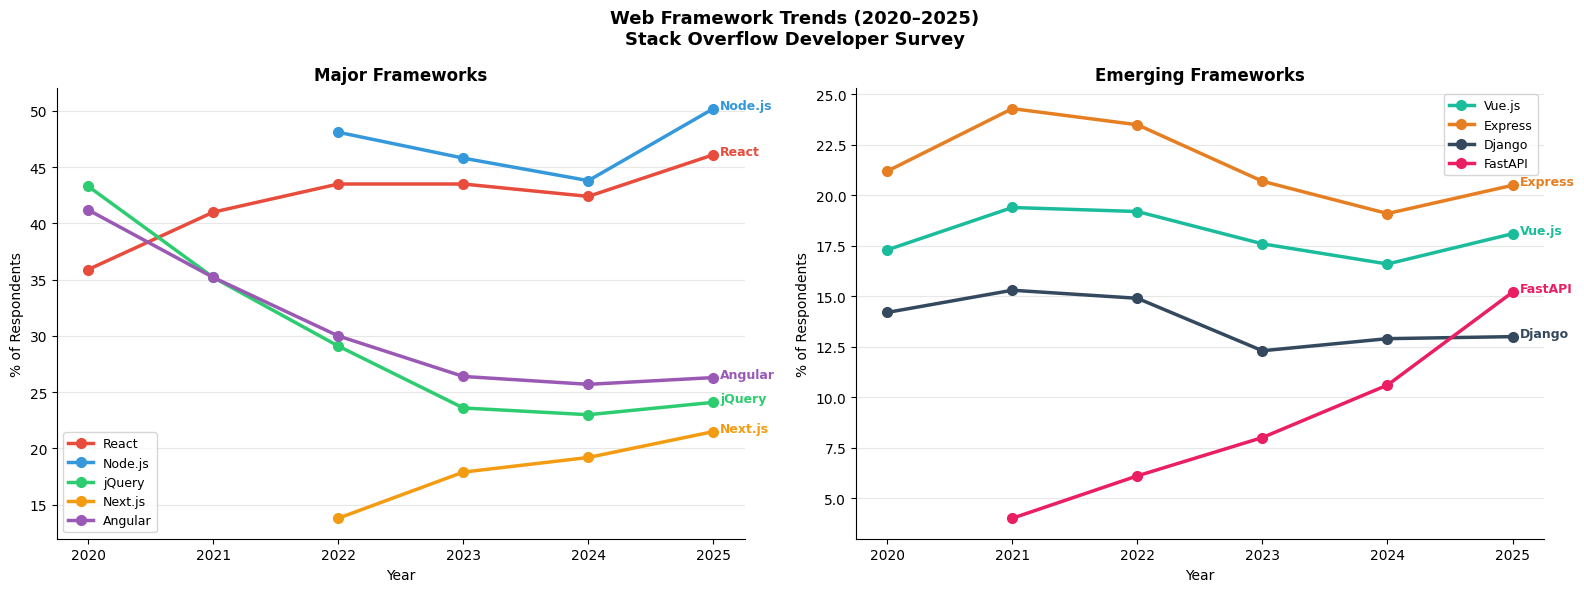

Chart saved.


In [41]:
# ============================================================
# CELL 35 — Web Framework Trends Chart
# ============================================================

track_frameworks = [
    'React', 'Node.js', 'jQuery',
    'Next.js', 'Angular', 'Vue.js',
    'Express', 'Django', 'FastAPI'
]

web_trend_data = {}

for fw in track_frameworks:
    yearly = (
        web_counts
        .filter(pl.col('framework').str.contains(fw))
        .group_by('survey_year')
        .agg(pl.col('pct').sum().alias('pct'))
        .sort('survey_year')
    )
    if yearly.shape[0] > 0:
        web_trend_data[fw] = {
            'years' : yearly['survey_year'].to_list(),
            'pct'   : yearly['pct'].to_list()
        }

# Split into two groups
fw_names = list(web_trend_data.keys())
group1   = fw_names[:5]
group2   = fw_names[5:]

colors_g1 = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']
colors_g2 = ['#1abc9c', '#e67e22', '#34495e', '#e91e63']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- Chart 1 ---
for i, fw in enumerate(group1):
    data = web_trend_data[fw]
    ax1.plot(data['years'], data['pct'], marker='o', linewidth=2.5,
             markersize=7, label=fw, color=colors_g1[i])
    ax1.annotate(fw,
        xy=(data['years'][-1], data['pct'][-1]),
        xytext=(5, 0), textcoords='offset points',
        fontsize=9, color=colors_g1[i], fontweight='bold')

ax1.set_title('Major Frameworks', fontsize=12, fontweight='bold')
ax1.set_xlabel('Year', fontsize=10)
ax1.set_ylabel('% of Respondents', fontsize=10)
ax1.set_xticks([2020, 2021, 2022, 2023, 2024, 2025])
ax1.legend(fontsize=9)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.grid(axis='y', alpha=0.3)

# --- Chart 2 ---
for i, fw in enumerate(group2):
    data = web_trend_data[fw]
    ax2.plot(data['years'], data['pct'], marker='o', linewidth=2.5,
             markersize=7, label=fw, color=colors_g2[i])
    ax2.annotate(fw,
        xy=(data['years'][-1], data['pct'][-1]),
        xytext=(5, 0), textcoords='offset points',
        fontsize=9, color=colors_g2[i], fontweight='bold')

ax2.set_title('Emerging Frameworks', fontsize=12, fontweight='bold')
ax2.set_xlabel('Year', fontsize=10)
ax2.set_ylabel('% of Respondents', fontsize=10)
ax2.set_xticks([2020, 2021, 2022, 2023, 2024, 2025])
ax2.legend(fontsize=9)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.grid(axis='y', alpha=0.3)

fig.suptitle('Web Framework Trends (2020–2025)\nStack Overflow Developer Survey',
             fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/developer_career_intelligence/exports/framework_trends.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved.")

In [42]:
# ============================================================
# CELL 36 — HR Analytics KPI Summary
# ============================================================

print("=" * 60)
print("   DEVELOPER CAREER INTELLIGENCE WAREHOUSE")
print("   HR Analytics KPI Summary (2020–2025)")
print("=" * 60)

# --- KPI 1: Total Respondents ---
total = master_df.shape[0]
print(f"\n  Total Survey Responses     : {total:,}")

# --- KPI 2: Countries Represented ---
countries = master_df.filter(
    pl.col('country').is_not_null()
)['country'].n_unique()
print(f"  Countries Represented      : {countries}")

# --- KPI 3: Unique Developer Roles ---
roles_unique = (
    master_df
    .filter(pl.col('dev_type').is_not_null())
    .select(pl.col('dev_type').str.split(';').explode())
    .unique()
    .shape[0]
)
print(f"  Unique Developer Roles     : {roles_unique}")

# --- KPI 4: Overall Median Salary ---
median_sal = salary_df['salary_usd'].median()
print(f"  Global Median Salary       : ${median_sal:,.0f}")

# --- KPI 5: Top Paying Country ---
top_country = country_salary.head(1)
print(f"  Top Paying Country         : {top_country['country'][0]} (${top_country['median_salary'][0]:,.0f})")

# --- KPI 6: Most Common Role ---
top_role = role_counts.head(1)
print(f"  Most Common Role           : {top_role['dev_type'][0]}")

# --- KPI 7: Top Language 2025 ---
top_lang_2025 = (
    lang_counts
    .filter(pl.col('survey_year') == 2025)
    .head(1)
)
print(f"  Top Language (2025)        : {top_lang_2025['language'][0]} ({top_lang_2025['pct'][0]}%)")

# --- KPI 8: Top Database 2025 ---
top_db_2025 = (
    db_counts
    .filter(pl.col('survey_year') == 2025)
    .head(1)
)
print(f"  Top Database (2025)        : {top_db_2025['database'][0]} ({top_db_2025['pct'][0]}%)")

# --- KPI 9: Top Framework 2025 ---
top_fw_2025 = (
    web_counts
    .filter(pl.col('survey_year') == 2025)
    .head(1)
)
print(f"  Top Framework (2025)       : {top_fw_2025['framework'][0]} ({top_fw_2025['pct'][0]}%)")

# --- KPI 10: Remote Work 2025 ---
remote_2025 = (
    master_df
    .filter(
        (pl.col('survey_year') == 2025) &
        pl.col('remote_work').is_not_null()
    )
    .group_by('remote_work')
    .agg(pl.len().alias('count'))
    .sort('count', descending=True)
)
top_remote = remote_2025.head(1)
total_remote = remote_2025['count'].sum()
remote_pct = round(top_remote['count'][0] / total_remote * 100, 1)
print(f"  Most Common Work Style     : {top_remote['remote_work'][0]} ({remote_pct}%)")

# --- KPI 11: Fastest Growing Language ---
# Compare 2020 vs 2025
lang_2020 = lang_counts.filter(pl.col('survey_year') == 2020).select(['language', 'pct'])
lang_2025 = lang_counts.filter(pl.col('survey_year') == 2025).select(['language', 'pct'])

lang_growth = (
    lang_2020
    .join(lang_2025, on='language', suffix='_2025')
    .with_columns(
        (pl.col('pct_2025') - pl.col('pct')).alias('growth')
    )
    .sort('growth', descending=True)
    .head(1)
)
print(f"  Fastest Growing Language   : {lang_growth['language'][0]} (+{lang_growth['growth'][0]}% since 2020)")

# --- KPI 12: Most Common Education ---
top_ed = (
    master_df
    .filter(pl.col('ed_level').is_not_null())
    .group_by('ed_level')
    .agg(pl.len().alias('count'))
    .sort('count', descending=True)
    .head(1)
)
print(f"  Most Common Education      : {top_ed['ed_level'][0]}")

print("\n" + "=" * 60)
print("  End of KPI Summary")
print("=" * 60)

   DEVELOPER CAREER INTELLIGENCE WAREHOUSE
   HR Analytics KPI Summary (2020–2025)

  Total Survey Responses     : 424,980
  Countries Represented      : 196
  Unique Developer Roles     : 50
  Global Median Salary       : $64,630
  Top Paying Country         : United States ($135,000)
  Most Common Role           : Developer, full-stack
  Top Language (2025)        : JavaScript (66.3%)
  Top Database (2025)        : PostgreSQL (56.9%)
  Top Framework (2025)       : Node.js (50.2%)
  Most Common Work Style     : Remote (32.4%)
  Fastest Growing Language   : TypeScript (+18.4% since 2020)
  Most Common Education      : Bachelor's degree

  End of KPI Summary
